# Bike-Share Station Availability Analysis

## Project Goal
This notebook analyzes bike-share station availability using station metadata and time-series status records.  
The main objective is to identify stations with persistent **empty**, **full**, or **operationally constrained** conditions, which are common signals of rebalancing inefficiency and service mismatch.

## Why this matters
For a bike-sharing platform, low availability directly affects user experience:
- **Empty stations** reduce trip origin reliability.
- **Full stations** reduce return reliability.
- **Unavailable docks/bikes** may indicate capacity mismatch or operational disruption.

## Deliverables
This notebook provides:
1. A reproducible data-cleaning pipeline  
2. Feature engineering for service reliability indicators  
3. Station-level and hourly analyses  
4. Visualizations that support operational decision-making  
5. A ranked list of high-risk stations

## 1. Imports and plotting setup

In [3]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import Normalize
from matplotlib import rcParams

rcParams['font.family'] = ['Yu Gothic', 'Times New Roman']
plt.rcParams["axes.unicode_minus"] = False
pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

In [4]:

# Create an output folder for README-ready figures
FIG_DIR = Path("images")
FIG_DIR.mkdir(parents=True, exist_ok=True)

def finalize_plot(filename=None):
    plt.tight_layout()
    if filename:
        plt.savefig(FIG_DIR / filename, dpi=300, bbox_inches="tight")
    plt.show()

def format_percent_axis(ax, axis="y"):
    import matplotlib.ticker as mtick
    if axis == "y":
        ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0, decimals=0))
    else:
        ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0, decimals=0))


## 2. File paths and reusable helpers
The notebook assumes the following local structure:

- `data_bike/station_information.json`
- `data_bike/status_2026-03-31.csv`

You can change the paths below if your files are stored elsewhere.

In [6]:
DATA_DIR = Path("data_bike")
INFO_PATH = DATA_DIR / "station_information.json"
STATUS_PATH = DATA_DIR / "status_2026-03-31.csv"

def validate_paths(*paths):
    missing = [str(p) for p in paths if not p.exists()]
    if missing:
        raise FileNotFoundError(
            "The following required files were not found:\n- " + "\n- ".join(missing)
        )

def top_share(series, n=10):
    return (series.sort_values(ascending=False).head(n) * 100).round(2)

validate_paths(INFO_PATH, STATUS_PATH)
INFO_PATH, STATUS_PATH

(WindowsPath('data_bike/station_information.json'),
 WindowsPath('data_bike/status_2026-03-31.csv'))

## 3. Load raw data

In [8]:
with open(INFO_PATH, encoding="utf-8") as f:
    station_info_raw = json.load(f)

df_info = pd.DataFrame(station_info_raw["data"]["stations"])
df_status = pd.read_csv(STATUS_PATH)

print("df_info shape:", df_info.shape)
print("df_status shape:", df_status.shape)

df_info shape: (1795, 6)
df_status shape: (34105, 4)


## 4. Inspect and clean raw tables
The goal here is to standardize dtypes and confirm basic data integrity before merging.

In [10]:
display(df_info.head())
display(df_status.head())

,lat,lon,name,capacity,region_id,station_id
0,35.693799,139.753281,A1-01.千代田区役所,8,1,00010001
1,35.701073,139.747525,A1-03.東京区政会館（メトロA5出口）,12,1,00010003
2,35.699187,139.746348,A1-05.富士見出張所,9,1,00010005
3,35.699132,139.744620,A1-08.飯田橋サクラテラス（早稲田通り）,20,1,00010036
4,35.696449,139.750784,A1-10.ヒューリック九段ビル,6,1,00010138


,station_id,num_bikes_available,num_docks_available,timestamp
0,10001,7,1,2026-03-31 18:05:28.803253
1,10003,10,2,2026-03-31 18:05:28.803253
2,10005,0,9,2026-03-31 18:05:28.803253
3,10036,19,0,2026-03-31 18:05:28.803253
4,10138,2,4,2026-03-31 18:05:28.803253


In [11]:
print("Missing values in station information:")
display(df_info.isna().sum().sort_values(ascending=False))

print("Missing values in status data:")
display(df_status.isna().sum().sort_values(ascending=False))

Missing values in station information:


lat           0
lon           0
name          0
capacity      0
region_id     0
station_id    0
dtype: int64

Missing values in status data:


station_id             0
num_bikes_available    0
num_docks_available    0
timestamp              0
dtype: int64

In [12]:
# Standardize key data types
df_info["station_id"] = pd.to_numeric(df_info["station_id"], errors="coerce").astype("Int64")
df_status["station_id"] = pd.to_numeric(df_status["station_id"], errors="coerce").astype("Int64")
df_status["num_bikes_available"] = pd.to_numeric(df_status["num_bikes_available"], errors="coerce")
df_status["num_docks_available"] = pd.to_numeric(df_status["num_docks_available"], errors="coerce")
df_status["timestamp"] = pd.to_datetime(df_status["timestamp"], errors="coerce")

# Drop rows that cannot be used
df_info = df_info.dropna(subset=["station_id", "lat", "lon"]).copy()
df_status = df_status.dropna(
    subset=["station_id", "num_bikes_available", "num_docks_available", "timestamp"]
).copy()

# Finalize dtypes
df_info["station_id"] = df_info["station_id"].astype(int)
df_status["station_id"] = df_status["station_id"].astype(int)
df_status["num_bikes_available"] = df_status["num_bikes_available"].astype(int)
df_status["num_docks_available"] = df_status["num_docks_available"].astype(int)

print("Cleaned df_info shape:", df_info.shape)
print("Cleaned df_status shape:", df_status.shape)

Cleaned df_info shape: (1795, 6)
Cleaned df_status shape: (34105, 4)


## 5. Merge tables and engineer analysis features
We construct interpretable indicators that can be used to measure station reliability.

In [14]:
df = pd.merge(df_info, df_status, on="station_id", how="inner")

# Capacity consistency check
df["num_unavailable"] = (
    df["capacity"] - df["num_bikes_available"] - df["num_docks_available"]
)

# Remove invalid zero-capacity stations from ratio analysis
df = df[df["capacity"] > 0].copy()

# Operational states
df["is_empty"] = (df["num_bikes_available"] == 0).astype(int)
df["is_full"] = (df["num_docks_available"] == 0).astype(int)
df["is_unavailable"] = (
    (df["num_unavailable"] > 0) | (df["num_bikes_available"] == 0) | (df["num_docks_available"] == 0)
).astype(int)

# Availability ratio
df["availability_ratio"] = df["num_bikes_available"] / df["capacity"]

# Time features
df["hour"] = df["timestamp"].dt.hour
df["date"] = df["timestamp"].dt.date

analysis_cols = [
    "station_id", "name", "region_id", "lat", "lon", "capacity",
    "num_bikes_available", "num_docks_available", "num_unavailable",
    "is_empty", "is_full", "is_unavailable", "availability_ratio",
    "timestamp", "hour", "date"
]
df = df[analysis_cols].sort_values(["station_id", "timestamp"]).reset_index(drop=True)

df.head()

,station_id,name,region_id,lat,lon,capacity,num_bikes_available,num_docks_available,num_unavailable,is_empty,is_full,is_unavailable,availability_ratio,timestamp,hour,date
0,109,D4-07.新宿余丁町ビル,5,35.698512,139.716482,5,2,3,0,0,0,0,0.4,2026-03-31 18:05:28.803253,18,2026-03-31
1,109,D4-07.新宿余丁町ビル,5,35.698512,139.716482,5,2,3,0,0,0,0,0.4,2026-03-31 18:15:29.093947,18,2026-03-31
2,109,D4-07.新宿余丁町ビル,5,35.698512,139.716482,5,1,4,0,0,0,0,0.2,2026-03-31 18:25:29.393904,18,2026-03-31
3,109,D4-07.新宿余丁町ビル,5,35.698512,139.716482,5,1,4,0,0,0,0,0.2,2026-03-31 18:35:29.687126,18,2026-03-31
4,109,D4-07.新宿余丁町ビル,5,35.698512,139.716482,5,1,4,0,0,0,0,0.2,2026-03-31 18:45:29.968135,18,2026-03-31


## 6. Data quality diagnostics
These checks are useful because abnormal counts can indicate sensor errors, scraping issues, or hidden station states.

In [16]:
capacity_mismatch = df[df["num_bikes_available"] + df["num_docks_available"] != df["capacity"]]
bike_over_capacity = df[df["num_bikes_available"] > df["capacity"]]

print("Rows with capacity mismatch:", len(capacity_mismatch))
print("Rows where bikes exceed capacity:", len(bike_over_capacity))

display(capacity_mismatch.head())
display(bike_over_capacity.head())

Rows with capacity mismatch: 8653
Rows where bikes exceed capacity: 1417


,station_id,name,region_id,lat,lon,capacity,num_bikes_available,num_docks_available,num_unavailable,is_empty,is_full,is_unavailable,availability_ratio,timestamp,hour,date
21,123,B3-18.銀座松竹スクエア,2,35.668395,139.769849,15,13,1,1,0,0,1,0.866667,2026-03-31 18:25:29.393904,18,2026-03-31
22,123,B3-18.銀座松竹スクエア,2,35.668395,139.769849,15,13,1,1,0,0,1,0.866667,2026-03-31 18:35:29.687126,18,2026-03-31
23,123,B3-18.銀座松竹スクエア,2,35.668395,139.769849,15,14,0,1,0,1,1,0.933333,2026-03-31 18:45:29.968135,18,2026-03-31
24,123,B3-18.銀座松竹スクエア,2,35.668395,139.769849,15,14,0,1,0,1,1,0.933333,2026-03-31 18:55:30.240658,18,2026-03-31
25,123,B3-18.銀座松竹スクエア,2,35.668395,139.769849,15,14,0,1,0,1,1,0.933333,2026-03-31 19:05:30.519632,19,2026-03-31


,station_id,name,region_id,lat,lon,capacity,num_bikes_available,num_docks_available,num_unavailable,is_empty,is_full,is_unavailable,availability_ratio,timestamp,hour,date
218,151,J1-39.松見坂公園,12,35.655483,139.687325,5,6,0,-1,0,1,1,1.200,2026-03-31 19:35:31.390803,19,2026-03-31
219,151,J1-39.松見坂公園,12,35.655483,139.687325,5,6,0,-1,0,1,1,1.200,2026-03-31 19:45:31.723238,19,2026-03-31
220,151,J1-39.松見坂公園,12,35.655483,139.687325,5,6,0,-1,0,1,1,1.200,2026-03-31 19:55:32.020206,19,2026-03-31
227,151,J1-39.松見坂公園,12,35.655483,139.687325,5,6,0,-1,0,1,1,1.200,2026-03-31 21:05:34.109103,21,2026-03-31
418,194,C1-71.芝商業高校前交差点,3,35.655830,139.759896,8,9,0,-1,0,1,1,1.125,2026-03-31 18:05:28.803253,18,2026-03-31


## 7. Station-level summary table
We aggregate the time-series records into interpretable station-level performance metrics.

In [18]:
station_summary = (
    df.groupby("station_id", as_index=False)
      .agg(
          station_name=("name", "first"),
          region_id=("region_id", "first"),
          lat=("lat", "first"),
          lon=("lon", "first"),
          capacity=("capacity", "first"),
          empty_ratio=("is_empty", "mean"),
          full_ratio=("is_full", "mean"),
          unavailable_ratio=("is_unavailable", "mean"),
          avg_availability_ratio=("availability_ratio", "mean"),
          avg_unavailable_slots=("num_unavailable", "mean"),
          observations=("timestamp", "count")
      )
)

# A simple composite risk score to rank problematic stations
station_summary["risk_score"] = (
    0.4 * station_summary["empty_ratio"]
    + 0.4 * station_summary["full_ratio"]
    + 0.2 * station_summary["unavailable_ratio"]
)

station_summary = station_summary.sort_values("risk_score", ascending=False).reset_index(drop=True)
station_summary.head(10)

,station_id,station_name,region_id,lat,lon,capacity,empty_ratio,full_ratio,unavailable_ratio,avg_availability_ratio,avg_unavailable_slots,observations,risk_score
0,2815,G5-06.錦糸町駅北口地下自転車駐車場,15,35.697521,139.813216,1,0.684211,1.000000,1.0,0.315789,0.684211,19,0.873684
1,928,Z22.みんちゅう京急川崎駅前駐輪場内ラックスペース,11,35.532615,139.700332,2,0.421053,0.842105,1.0,0.447368,0.789474,19,0.705263
2,4363,H1-246.白河1丁目 大和物産 非常階段下,4,35.682249,139.799937,1,0.526316,0.684211,1.0,0.473684,0.210526,19,0.684211
3,3563,K1-167.Luz大森2,7,35.586665,139.728134,1,0.894737,0.315789,1.0,0.105263,0.210526,19,0.684211
4,3359,I1-122.エルフォルテ 五反田,10,35.618661,139.718570,2,0.315789,0.789474,1.0,0.657895,0.263158,19,0.642105
5,10195,C3-11.赤坂見附南,3,35.676566,139.737083,6,0.210526,0.894737,1.0,0.385965,3.578947,19,0.642105
6,3920,C1-89.VORT 新橋Ⅲ,3,35.663251,139.757235,1,1.000000,0.052632,1.0,0.000000,0.052632,19,0.621053
7,10374,T2-11.石神井松の風文化公園,9,35.739175,139.593051,2,0.473684,0.578947,1.0,0.526316,0.105263,19,0.621053
8,3789,F4-07.ティモーネプレミアム三ノ輪ステーション,18,35.729518,139.790615,1,0.052632,1.000000,1.0,0.947368,0.052632,19,0.621053
9,10364,T2-01.大泉学園駅北口,9,35.749918,139.586180,1,0.736842,0.315789,1.0,0.263158,-0.421053,19,0.621053


## 8. Summary statistics

In [20]:
summary_stats = station_summary[
    ["capacity", "empty_ratio", "full_ratio", "unavailable_ratio", "avg_availability_ratio", "risk_score"]
].describe().T

summary_stats

,count,mean,std,min,25%,50%,75%,max
capacity,1787.0,10.843313,10.196395,1.0,5.000000,8.000000,13.000000,107.000000
empty_ratio,1787.0,0.177569,0.325479,0.0,0.000000,0.000000,0.184211,1.000000
full_ratio,1787.0,0.183813,0.353824,0.0,0.000000,0.000000,0.052632,1.000000
unavailable_ratio,1787.0,0.438488,0.398322,0.0,0.052632,0.315789,0.894737,1.000000
avg_availability_ratio,1787.0,0.458679,0.366535,0.0,0.157895,0.388158,0.732057,3.210526
risk_score,1787.0,0.232250,0.241817,0.0,0.010526,0.126316,0.484211,0.873684


## 9. Spatial distribution of stations
A dense cluster may indicate better service coverage, but not necessarily better balance.

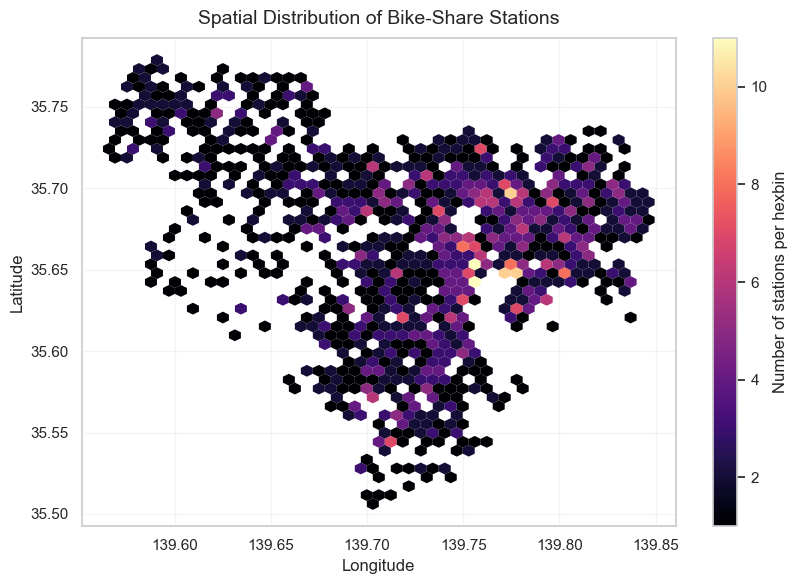

In [22]:

fig, ax = plt.subplots(figsize=(8.5, 6))
hb = ax.hexbin(
    station_summary["lon"],
    station_summary["lat"],
    gridsize=45,
    cmap="magma",
    mincnt=1,
    linewidths=0
)
cb = fig.colorbar(hb, ax=ax)
cb.set_label("Number of stations per hexbin")

ax.set_title("Spatial Distribution of Bike-Share Stations", fontsize=14, pad=10)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.grid(alpha=0.2)

finalize_plot("station_spatial_distribution.png")


## 10. Temporal reliability patterns
Hourly patterns help reveal when system imbalance is most likely to affect users.

In [24]:
hourly_profile = (
    df.groupby("hour")
      .agg(
          empty_ratio=("is_empty", "mean"),
          full_ratio=("is_full", "mean"),
          unavailable_ratio=("is_unavailable", "mean"),
          avg_availability_ratio=("availability_ratio", "mean")
      )
      .reset_index()
)

hourly_profile

,hour,empty_ratio,full_ratio,unavailable_ratio,avg_availability_ratio
0,18,0.181030,0.183361,0.416900,0.451674
1,19,0.180750,0.181030,0.439377,0.455128
2,20,0.172356,0.186159,0.455325,0.465996
3,21,0.168998,0.189144,0.461668,0.478123


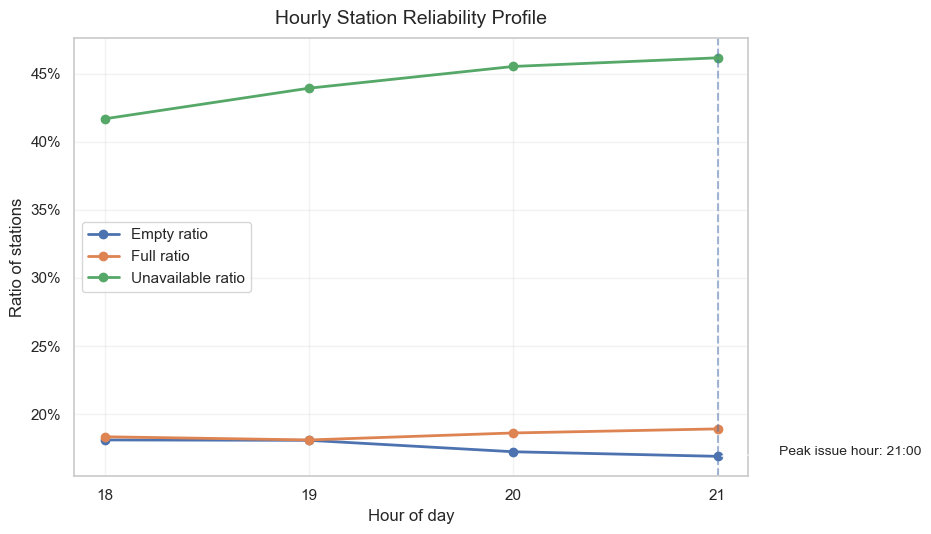

In [25]:

fig, ax = plt.subplots(figsize=(9.5, 5.5))

ax.plot(hourly_profile["hour"], hourly_profile["empty_ratio"], marker="o", linewidth=2, label="Empty ratio")
ax.plot(hourly_profile["hour"], hourly_profile["full_ratio"], marker="o", linewidth=2, label="Full ratio")
ax.plot(hourly_profile["hour"], hourly_profile["unavailable_ratio"], marker="o", linewidth=2, label="Unavailable ratio")

# Highlight the most problematic hour for total service failure
hourly_profile["combined_issue"] = (
    hourly_profile["empty_ratio"] + hourly_profile["full_ratio"] + hourly_profile["unavailable_ratio"]
)
peak_row = hourly_profile.loc[hourly_profile["combined_issue"].idxmax()]
ax.axvline(peak_row["hour"], linestyle="--", alpha=0.5)
ax.annotate(
    f'Peak issue hour: {int(peak_row["hour"]):02d}:00',
    xy=(peak_row["hour"], peak_row["empty_ratio"]),
    xytext=(peak_row["hour"] + 0.3, max(hourly_profile["empty_ratio"].max(), hourly_profile["full_ratio"].max()) * 0.9),
    arrowprops=dict(arrowstyle="->", alpha=0.6),
    fontsize=10
)

ax.set_title("Hourly Station Reliability Profile", fontsize=14, pad=10)
ax.set_xlabel("Hour of day")
ax.set_ylabel("Ratio of stations")
ax.set_xticks(sorted(hourly_profile["hour"].unique()))
format_percent_axis(ax, "y")
ax.legend(frameon=True)
ax.grid(alpha=0.25)

finalize_plot("hourly_station_reliability_profile.png")


## 11. Top high-risk stations
These stations are the strongest candidates for rebalancing, capacity review, or local demand investigation.

In [27]:
top_risk = station_summary[
    ["station_id", "station_name", "capacity", "empty_ratio", "full_ratio",
     "unavailable_ratio", "avg_availability_ratio", "risk_score"]
].head(10).copy()

for col in ["empty_ratio", "full_ratio", "unavailable_ratio", "avg_availability_ratio", "risk_score"]:
    top_risk[col] = (top_risk[col] * 100).round(2)

top_risk

,station_id,station_name,capacity,empty_ratio,full_ratio,unavailable_ratio,avg_availability_ratio,risk_score
0,2815,G5-06.錦糸町駅北口地下自転車駐車場,1,68.42,100.00,100.0,31.58,87.37
1,928,Z22.みんちゅう京急川崎駅前駐輪場内ラックスペース,2,42.11,84.21,100.0,44.74,70.53
2,4363,H1-246.白河1丁目 大和物産 非常階段下,1,52.63,68.42,100.0,47.37,68.42
3,3563,K1-167.Luz大森2,1,89.47,31.58,100.0,10.53,68.42
4,3359,I1-122.エルフォルテ 五反田,2,31.58,78.95,100.0,65.79,64.21
5,10195,C3-11.赤坂見附南,6,21.05,89.47,100.0,38.60,64.21
6,3920,C1-89.VORT 新橋Ⅲ,1,100.00,5.26,100.0,0.00,62.11
7,10374,T2-11.石神井松の風文化公園,2,47.37,57.89,100.0,52.63,62.11
8,3789,F4-07.ティモーネプレミアム三ノ輪ステーション,1,5.26,100.00,100.0,94.74,62.11
9,10364,T2-01.大泉学園駅北口,1,73.68,31.58,100.0,26.32,62.11


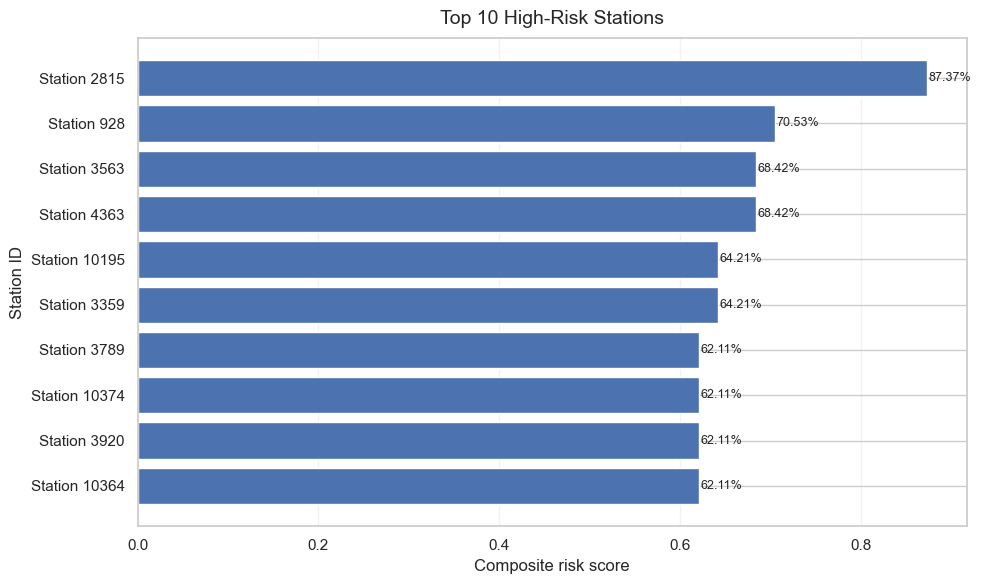

In [28]:

top_risk_plot = station_summary.nlargest(10, "risk_score").sort_values("risk_score", ascending=True).copy()
top_risk_plot["station_label"] = [f"Station {sid}" for sid in top_risk_plot["station_id"]]

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top_risk_plot["station_label"], top_risk_plot["risk_score"])
ax.set_title("Top 10 High-Risk Stations", fontsize=14, pad=10)
ax.set_xlabel("Composite risk score")
ax.set_ylabel("Station ID")
ax.grid(axis="x", alpha=0.25)

for i, v in enumerate(top_risk_plot["risk_score"]):
    ax.text(v + 0.002, i, f"{v:.2%}", va="center", fontsize=9)

finalize_plot("top_10_high_risk_stations.png")


## 12. Spatial view of problematic stations
The three plots below separate different failure modes:
- empty-origin risk
- full-return risk
- overall station unavailability

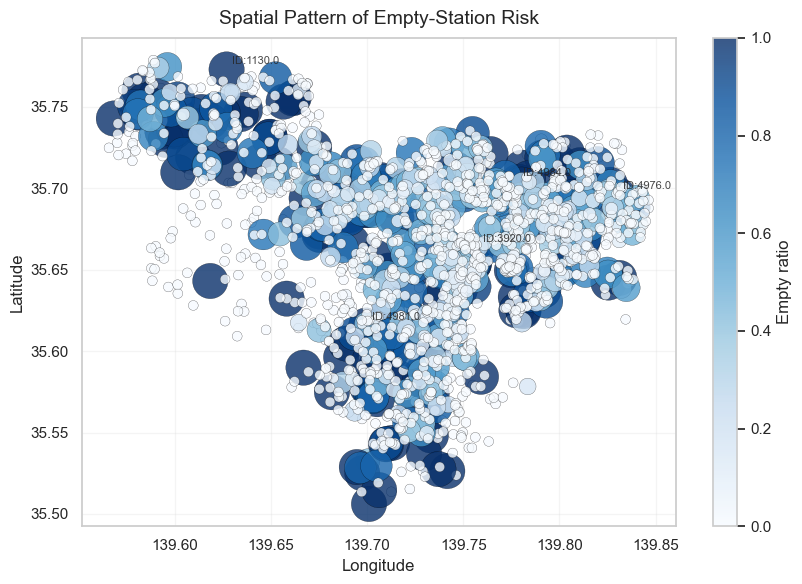

In [30]:

top_points = station_summary.nlargest(5, "empty_ratio")[["station_id", "lon", "lat", "empty_ratio"]].copy()

fig, ax = plt.subplots(figsize=(8.5, 6))
sc = ax.scatter(
    station_summary["lon"],
    station_summary["lat"],
    c=station_summary["empty_ratio"],
    s=50 + station_summary["empty_ratio"] * 600,
    cmap="Blues",
    alpha=0.8,
    edgecolor="black",
    linewidth=0.2
)
cb = fig.colorbar(sc, ax=ax)
cb.set_label("Empty ratio")

for _, row in top_points.iterrows():
    ax.annotate(
        f'ID:{row["station_id"]}',
        (row["lon"], row["lat"]),
        xytext=(4, 4),
        textcoords="offset points",
        fontsize=8,
        alpha=0.85
    )

ax.set_title("Spatial Pattern of Empty-Station Risk", fontsize=14, pad=10)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.grid(alpha=0.2)

finalize_plot("spatial_empty_station_risk.png")


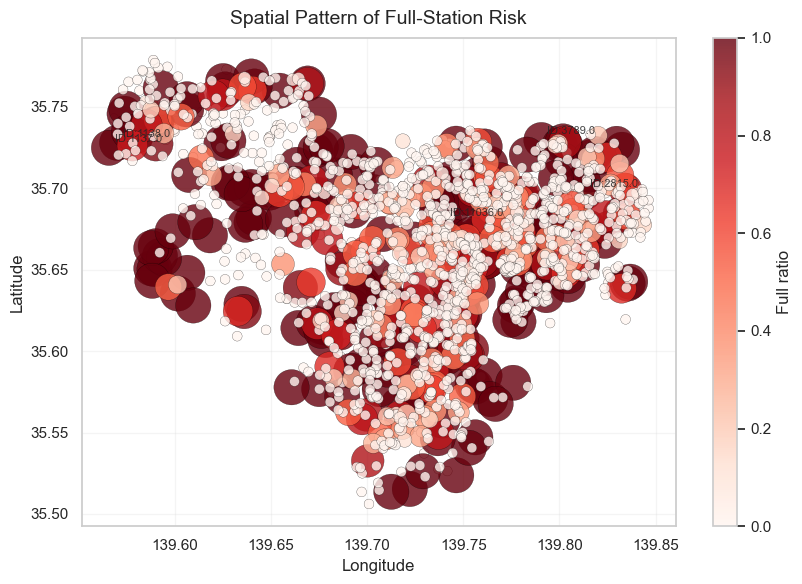

In [31]:

top_points = station_summary.nlargest(5, "full_ratio")[["station_id", "lon", "lat", "full_ratio"]].copy()

fig, ax = plt.subplots(figsize=(8.5, 6))
sc = ax.scatter(
    station_summary["lon"],
    station_summary["lat"],
    c=station_summary["full_ratio"],
    s=50 + station_summary["full_ratio"] * 600,
    cmap="Reds",
    alpha=0.8,
    edgecolor="black",
    linewidth=0.2
)
cb = fig.colorbar(sc, ax=ax)
cb.set_label("Full ratio")

for _, row in top_points.iterrows():
    ax.annotate(
        f'ID:{row["station_id"]}',
        (row["lon"], row["lat"]),
        xytext=(4, 4),
        textcoords="offset points",
        fontsize=8,
        alpha=0.85
    )

ax.set_title("Spatial Pattern of Full-Station Risk", fontsize=14, pad=10)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.grid(alpha=0.2)

finalize_plot("spatial_full_station_risk.png")


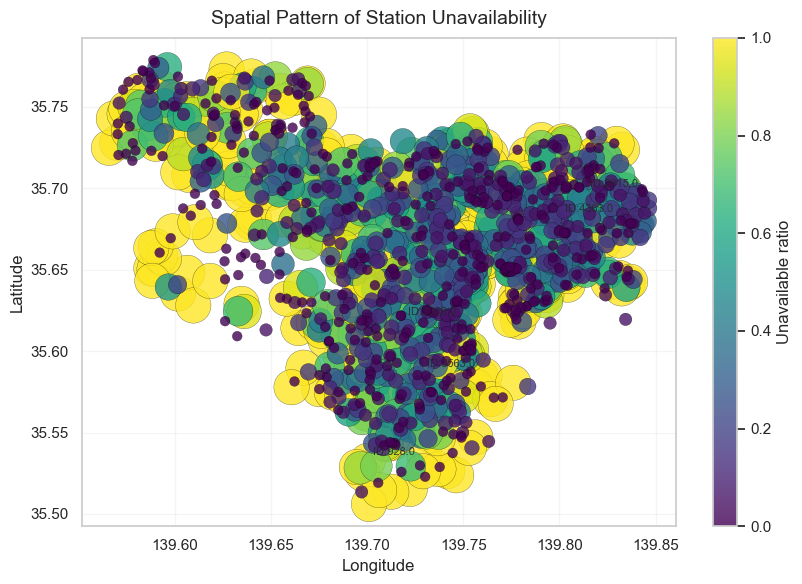

In [32]:

top_points = station_summary.nlargest(5, "unavailable_ratio")[["station_id", "lon", "lat", "unavailable_ratio"]].copy()

fig, ax = plt.subplots(figsize=(8.5, 6))
sc = ax.scatter(
    station_summary["lon"],
    station_summary["lat"],
    c=station_summary["unavailable_ratio"],
    s=50 + station_summary["unavailable_ratio"] * 600,
    cmap="viridis",
    alpha=0.8,
    edgecolor="black",
    linewidth=0.2
)
cb = fig.colorbar(sc, ax=ax)
cb.set_label("Unavailable ratio")

for _, row in top_points.iterrows():
    ax.annotate(
        f'ID:{row["station_id"]}',
        (row["lon"], row["lat"]),
        xytext=(4, 4),
        textcoords="offset points",
        fontsize=8,
        alpha=0.85
    )

ax.set_title("Spatial Pattern of Station Unavailability", fontsize=14, pad=10)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.grid(alpha=0.2)

finalize_plot("spatial_station_unavailability.png")


## 13. Relationship between capacity and reliability
This helps check whether larger stations are consistently more stable or whether imbalance is demand-driven.

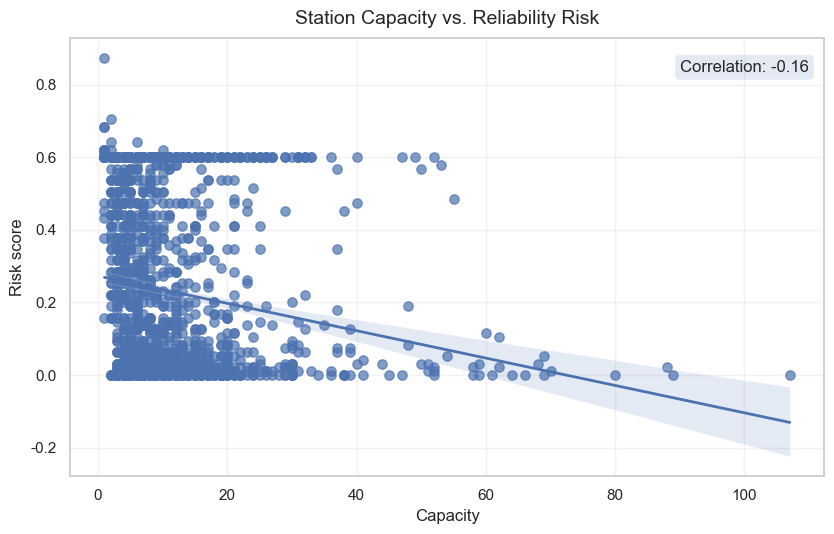

In [34]:

fig, ax = plt.subplots(figsize=(8.5, 5.5))
sns.regplot(
    data=station_summary,
    x="capacity",
    y="risk_score",
    scatter_kws={"alpha": 0.7, "s": 45},
    line_kws={"linewidth": 2},
    ax=ax
)

corr = station_summary[["capacity", "risk_score"]].corr().iloc[0, 1]
ax.text(
    0.98, 0.95, f"Correlation: {corr:.2f}",
    transform=ax.transAxes,
    ha="right", va="top",
    bbox=dict(boxstyle="round,pad=0.3", alpha=0.15)
)

ax.set_title("Station Capacity vs. Reliability Risk", fontsize=14, pad=10)
ax.set_xlabel("Capacity")
ax.set_ylabel("Risk score")
ax.grid(alpha=0.25)

finalize_plot("capacity_vs_reliability_risk.png")


## 14. Export results
You can use these outputs in a dashboard, report, or map workflow later.

In [36]:
output_dir = Path("outputs")
output_dir.mkdir(exist_ok=True)

station_summary.to_csv(output_dir / "station_summary.csv", index=False)
hourly_profile.to_csv(output_dir / "hourly_profile.csv", index=False)
top_risk.to_csv(output_dir / "top_risk_stations.csv", index=False)

print(f"Saved files to: {output_dir.resolve()}")

Saved files to: C:\Users\Administrator\Homework\Study\Step_1 python and data analysis\outputs


## 15. Conclusion
### Key takeaways
1. Station reliability can be interpreted through repeated empty/full states rather than a single snapshot.
2. High-risk stations should be prioritized for rebalancing and field investigation.
3. Hourly variation provides a useful operational signal for time-specific dispatch planning.

### Recommended next steps
- Add weekday/weekend comparison
- Link stations to nearby rail stations or land-use types
- Build a prediction model for empty/full events
- Evaluate whether station capacity should be expanded at persistently constrained locations